# An introduction to Finite Element Analysis (FEA) - 2D plate example

## Finite element analysis procedure

1. **Define the Geometry:**
   - Specify the geometry of the problem and discretise it into nodes.
   - Choose appropriate elements for the discretisation, e.g., triangular elements.
2. **Material Properties:**
   - Define the material properties of the material, as an example, for a linear elastic material the Young's modulus ($E$) and Poisson's ratio ($\nu$) must be defined.
3. **Mesh Generation:**
   - Create a mesh using the specified nodes and elements.
   - Tools like Delaunay triangulation can be used for mesh generation.
4. **Element Stiffness Matrix:**
   - Develop the local stiffness matrix for each triangular element.
   - Incorporate material properties and element geometry into the formulation.
5. **Assemble Global Stiffness Matrix:**
   - Assemble the global stiffness matrix by summing contributions from individual elements.
   - Account for boundary conditions during assembly.
6. **Apply Boundary Conditions:**
   - Set up and apply boundary conditions to the global stiffness matrix.
   - This may involve fixing certain degrees of freedom or applying prescribed displacements.
7. **Apply Loads:**
   - Apply external loads to the system by modifying the right-hand side of the equilibrium equation.
8. **Solve Linear System:**
   - Solve the linear system of equations using numerical methods (e.g., direct solvers or iterative methods).
   - The solution provides the nodal displacements.
9. **Post-Processing:**
   - Calculate and visualise additional quantities of interest, such as stresses, strains, and reactions.
   - Evaluate the results at specific points or along element edges.

### Element (Local) stiffness matrix

Creating the local stiffness matrix for a triangular element involves several steps.

1. **Shape Functions:**
   - Start by generating the shape functions for the triangular element. These shape functions $(N_1, \; N_2, \; N_3)$ describe how the field variable (e.g., displacement) varies across the element.
2. **Derivative of Shape Functions:**
   - Compute the derivatives of the shape functions $(\frac{\partial N_i}{\partial x}, \frac{\partial N_i}{\partial y})$ with respect to the natural coordinates $(\xi, \; \eta)$. These derivatives are required for mapping from natural coordinates to physical coordinates.
3. **Jacobian Matrix:**
   - Construct the Jacobian matrix $(J)$ using the derivatives of the shape functions and the nodal coordinates. The Jacobian matrix relates the derivatives of the shape functions in natural coordinates to the derivatives in physical coordinates.
4. **Inverse of Jacobian:**
   - Calculate the inverse of the Jacobian matrix $(J^{-1})$. This is needed to transform the derivatives of the shape functions from physical coordinates to natural coordinates.
5. **B Matrix (Strain-Displacement Matrix):**
   - Using the inverse Jacobian, construct the B matrix $(B)$ for the triangular element. The B matrix relates the strain at a point to the nodal displacements and is given by:
     $$B = \begin{bmatrix}
              \frac{\partial N_1}{\partial x} & 0 & \frac{\partial N_2}{\partial x} & 0 & \frac{\partial N_3}{\partial x} & 0 \\
              0 & \frac{\partial N_1}{\partial y} & 0 & \frac{\partial N_2}{\partial y} & 0 & \frac{\partial N_3}{\partial y} \\
              \frac{\partial N_1}{\partial y} & \frac{\partial N_1}{\partial x} & \frac{\partial N_2}{\partial y} & \frac{\partial N_2}                {\partial x} & \frac{\partial N_3}{\partial y} & \frac{\partial N_3}{\partial x} \\
           \end{bmatrix}$$
6. **Material Stiffness Matrix:**
   - Define the material properties of the element, such as Young's modulus $(E)$ and Poisson's ratio $(v)$. Use these properties to compute the material stiffness matrix $(D)$.
7. **Element Stiffness Matrix:**
   - Combine the $B$ matrix and material stiffness matrix to obtain the local stiffness matrix $(K_{\text{local}})$ for the triangular element: $$K_{\text{local}} = t \cdot B^T \cdot D \cdot B \cdot \text{det}(J)$$
   - Here, $t$ is the element thickness, and $\text{det}(J)$ is the determinant of the Jacobian matrix.
8. **Assembly:**
   - Repeat the above steps for each element in the mesh to create local stiffness matrices $(K_{\text{local}}^1, \; K_{\text{local}}^2, \; \ldots \;)$
9. **Global Stiffness Matrix:**
   - Assemble the local stiffness matrices into the global stiffness matrix $(K_{\text{global}})$ based on the connectivity of nodes in the mesh.

The resulting global stiffness matrix is then used to solve the system of linear equations representing the equilibrium of the structure under applied loads and boundary conditions. The solution provides the nodal displacements and, consequently, the deformation of the structure.

### B Matrix (Strain-Displacement Matrix)

The strain-displacement matrix, often denoted as the B matrix, relates strains to nodal displacements in the finite element method. For a linear elastic triangular element, let us consider a two-dimensional plane stress or plane strain situation. The triangular element is typically defined by three nodes, and each node has two degrees of freedom (DOFs) for displacements (one in the $x$-direction and one in the $y$-direction).

Let's denote the nodal displacements as $u$ and $v$ for the $x$ and $y$ directions, respectively. The displacement vector for a node can be written as $[u, v]$.

For a linear elastic triangular element, the strain-displacement matrix (B matrix) can be expressed as:

$$\mathbf{B} = \begin{bmatrix}
\frac{\partial N_1}{\partial x} & 0 & \frac{\partial N_2}{\partial x} & 0 & \frac{\partial N_3}{\partial x} & 0 \\
0 & \frac{\partial N_1}{\partial y} & 0 & \frac{\partial N_2}{\partial y} & 0 & \frac{\partial N_3}{\partial y} \\
\frac{\partial N_1}{\partial y} & \frac{\partial N_1}{\partial x} & \frac{\partial N_2}{\partial y} & \frac{\partial N_2}{\partial x} & \frac{\partial N_3}{\partial y} & \frac{\partial N_3}{\partial x}
\end{bmatrix}$$

Here, $N_1$, $N_2$, and $N_3$ are the shape functions associated with the three nodes of the triangular element. The shape functions depend on the local coordinates (usually denoted as $\xi$ and $\eta$).

The derivatives of the shape functions with respect to the local coordinates are involved in the B matrix. For linear triangular elements, these derivatives are constants, and the B matrix simplifies further. The shape functions and their derivatives can be determined based on the element's geometry and interpolation functions used.

It's important to note that the expressions may vary slightly depending on the specific formulation or coordinate system used (e.g., Cartesian or natural coordinates). Additionally, the above formulation assumes plane stress or plane strain conditions.

### B Matrix - linear elastic triangular element

Here we provide a more detailed explanation of the simplification of the B matrix for a linear elastic triangular element.

For a linear triangular element, the shape functions ($N_1$, $N_2$, and $N_3$) and their derivatives with respect to the local coordinates ($\xi$) and ($\eta$) can be expressed as follows:

$$ N_1 = \xi, \quad N_2 = \eta, \quad N_3 = 1 - \xi - \eta $$

The derivatives with respect to the local coordinates are:

$$ \frac{\partial N_1}{\partial \xi} = 1, \quad \frac{\partial N_1}{\partial \eta} = 0 $$
$$ \frac{\partial N_2}{\partial \xi} = 0, \quad \frac{\partial N_2}{\partial \eta} = 1 $$
$$ \frac{\partial N_3}{\partial \xi} = -1, \quad \frac{\partial N_3}{\partial \eta} = -1 $$

Using these shape functions and their derivatives, the B matrix for a linear elastic triangular element simplifies to:

**THIS IS WRONG!**

$$ \mathbf{B} = \begin{bmatrix}
1 & 0 & -1 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 & -1 & 0 \\
0 & 1 & 0 & -1 & 0 & 0
\end{bmatrix} $$

This is the simplified form of the B matrix for a linear elastic triangular element in 2D. The specific values in the matrix depend on the nodal numbering and the order of the shape functions used, but the overall structure remains similar. This B matrix relates the nodal displacements to strains in a linear elastic triangular element.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import fea

## 1. Define the material properties

`Material(name, E, v, ConstitutiveModel)`

In [2]:
steel = fea.Material(E=200e9, v=0.28, constitutive_model=fea.LinearElasticModel)

## 2. Build mesh

Build a mesh (instance of the `Mesh` class) where `Mesh.elements` is a list of triangular elements. Each triangular element is an instance of the `TriangularElement` class

In [3]:
def build_nodes(dx, n_div_x, n_div_y):
    """
    Build nodes
    """
    nodes = np.zeros([n_div_x * n_div_y, 2])
    counter = 0

    for i_y in range(n_div_y):  # Depth
        for i_x in range(n_div_x):  # Length
            coord_x = dx * i_x
            coord_y = dx * i_y
            nodes[counter, 0] = coord_x
            nodes[counter, 1] = coord_y
            counter += 1

    return nodes

Number of nodes: 12500
Number of elements: 24402


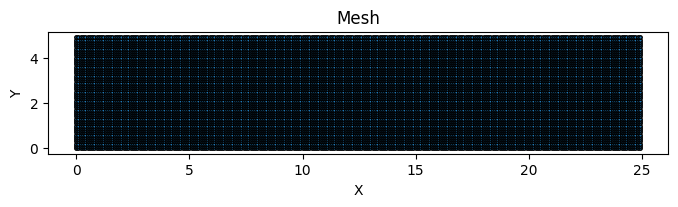

In [4]:
length = 25
depth = 5
dx = 0.1

n_div_x = int(length / dx)
n_div_y = int(depth / dx)

points = build_nodes(dx, n_div_x, n_div_y) # 8, 4
mesh = fea.Mesh(points, steel, t=1)
mesh.plot(nodes=False, simplices=False)
mesh.info()

In [5]:
simplices = 2
print(mesh.elements[simplices].nodes)
print(mesh.elements[simplices].vertices)
print(mesh.elements[simplices].area)

[3843 3593 3594]
[[9.3 1.5]
 [9.3 1.4]
 [9.4 1.4]]
0.004999999999999976


In [6]:
# dogbone = np.genfromtxt('dogbone.csv', delimiter=',', skip_header=1)

# x = dogbone[:, 1]
# y = dogbone[:, 2]
# points = np.column_stack((x, y))

# mesh = fea.Mesh(points, steel, t=1)
# mesh.plot(nodes=False, simplices=False)
# mesh.info()

## 3. Build boundary conditions

Build an instance of the `BoundaryConditions` class

- `BoundaryConditions.magnitude` is a force
- Is `BoundaryConditions.flag` needed?

### 3.1 Applied Forces

In [7]:
def build_applied_forces(particles, dx, n_div_x):
    bc_flag = np.zeros((len(particles), 2), dtype=np.intc)
    bc_unit_vector = np.zeros((len(particles), 2), dtype=np.intc)

    for i, particle in enumerate(particles):
        if particle[0] > (dx * (n_div_x - 1.5)):
            bc_flag[i, 1] = 1
            bc_unit_vector[i, 1] = -1

    return bc_flag, bc_unit_vector

In [8]:
flag, unit_vector = build_applied_forces(points, dx, n_div_x)

magnitude = 1e5
bc = fea.BoundaryConditions(flag, unit_vector, magnitude)

### 3.2 Constraints

In [9]:
def build_constraints(particles, dx):
    bc_flag = np.zeros((len(particles), 2), dtype=np.intc)

    for i, particle in enumerate(particles):
        if particle[0] < dx:
            bc_flag[i, :] = 1

    return bc_flag

In [10]:
constraints = build_constraints(points, dx)

## 4. Build the complete model

In [11]:
plate = fea.Model(mesh, bc, constraints)

### 4.1 Visualise the global stiffness matrix

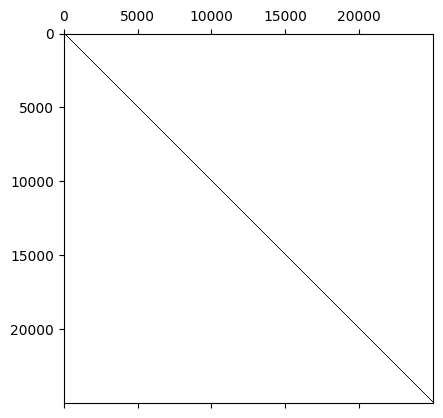

In [12]:
plt.spy(plate.K)

### 4.2 Visualise the boundary conditions

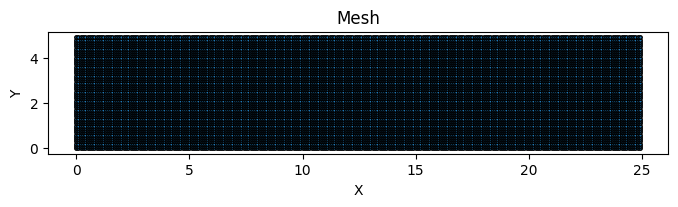

In [13]:
plate.plot_boundary_conditions()

## 5. Solve

In [ ]:
plate.solve()
plate.plot_solution(dsf=100)

In [ ]:
plate.plot_u(1)

### Stress and strain

In [ ]:
plate.plot_stress()

## Gaussian Process Regression

1. Run 100+ simulations of a loaded 2D plate with variable dimensions and material parameters
2. Gaussian process regression
3. Predict the response of a 2D plate with quantified levels of uncertainty

In [ ]:
# array = np.array([[1, 2], [3, 4], [5, 6], [7, 8], [9, 10]])
# array_reshaped = array.reshape(-1, 1)
# array_flatten = array.flatten()

# print(array, array.shape)
# print(array_reshaped, array_reshaped.shape)
# print(array_flatten, array_flatten.shape)
# print(np.reshape(array_reshaped, (-1, 2)))
# print(np.reshape(array_flatten, (-1, 2)))